<a href="https://colab.research.google.com/github/Soumit2k05/MP-1-7th-Sem-Soumit-Subhasish-Roshan-Rajaram/blob/main/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install Libraries**

In [ ]:
!pip install pandas matplotlib seaborn

**Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("PJME_hourly.csv", parse_dates=['Datetime'], index_col='Datetime')
df = df.sort_index().dropna()

df['Hour']    = df.index.hour
df['Day']     = df.index.day
df['Month']   = df.index.month
df['Weekday'] = df.index.weekday
df['Weekend'] = (df.index.dayofweek >= 5).astype(int)
df['Quarter'] = df.index.quarter
df['Year']    = df.index.year
df['Lag_1']   = df['PJME_MW'].shift(1)
df['Lag_24']  = df['PJME_MW'].shift(24)
df['Lag_168'] = df['PJME_MW'].shift(168)
df['Rolling_Mean_24']  = df['PJME_MW'].rolling(24).mean()
df['Rolling_Mean_168'] = df['PJME_MW'].rolling(168).mean()
df.dropna(inplace=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (145198, 13)


,PJME_MW,Hour,Day,Month,Weekday,Weekend,Quarter,Year,Lag_1,Lag_24,Lag_168,Rolling_Mean_24,Rolling_Mean_168
Datetime,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,8,1,1,0,1,2002,31187.0,26862.0,30393.0,33560.208333,32513.869048
2002-01-08 02:00:00,28670.0,2,8,1,1,0,1,2002,29445.0,25976.0,29265.0,33672.458333,32510.327381
2002-01-08 03:00:00,28375.0,3,8,1,1,0,1,2002,28670.0,25641.0,28357.0,33786.375000,32510.434524
2002-01-08 04:00:00,28542.0,4,8,1,1,0,1,2002,28375.0,25666.0,27899.0,33906.208333,32514.261905
2002-01-08 05:00:00,29261.0,5,8,1,1,0,1,2002,28542.0,26328.0,28057.0,34028.416667,32521.428571


**Load Cleaned Dataset and view it**

In [14]:
print(f"Shape: {df.shape}")

df.head()

print(df.info())

print(df.describe())

Shape: (145366, 1)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB
None
             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000


In [16]:
if 'Month' not in df.columns:
    df['Hour']    = df.index.hour
    df['Day']     = df.index.day
    df['Month']   = df.index.month
    df['Weekday'] = df.index.weekday
    df['Weekend'] = (df.index.dayofweek >= 5).astype(int)
    df['Quarter'] = df.index.quarter
    df['Year']    = df.index.year
    print("Generated missing time-based features: Hour, Day, Month, Weekday, Weekend, Quarter, Year.")
else:
    print("Time-based features (Hour, Day, Month, Weekday, Weekend, Quarter, Year) already exist.")

Generated missing time-based features: Hour, Day, Month, Weekday, Weekend, Quarter, Year.


**Time Series Plot**

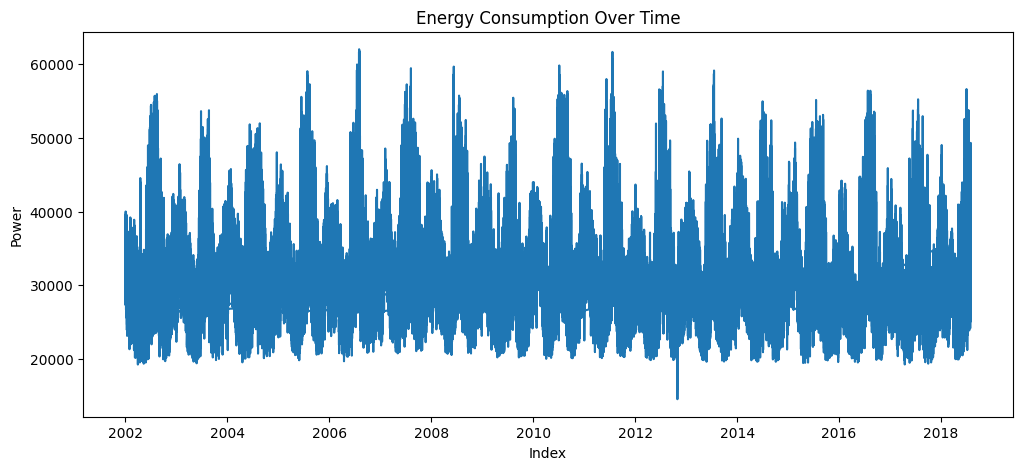

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df["PJME_MW"])
plt.title("Energy Consumption Over Time")
plt.xlabel("Index")
plt.ylabel("Power")
plt.show()

**Histogram**

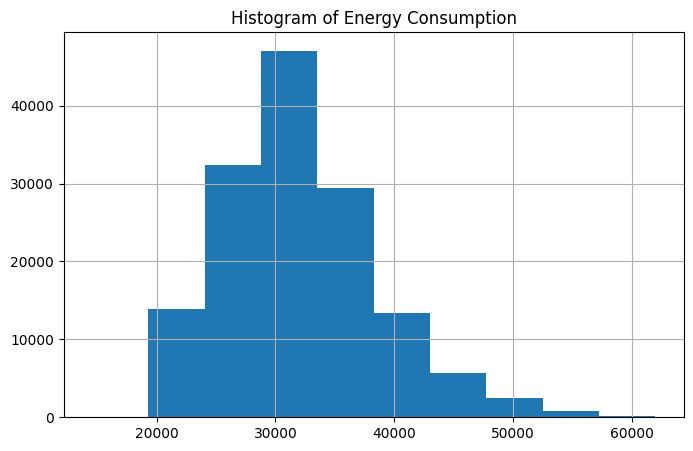

In [9]:
df["PJME_MW"].hist(figsize=(8,5))
plt.title("Histogram of Energy Consumption")
plt.show()

**Monthly Trend**

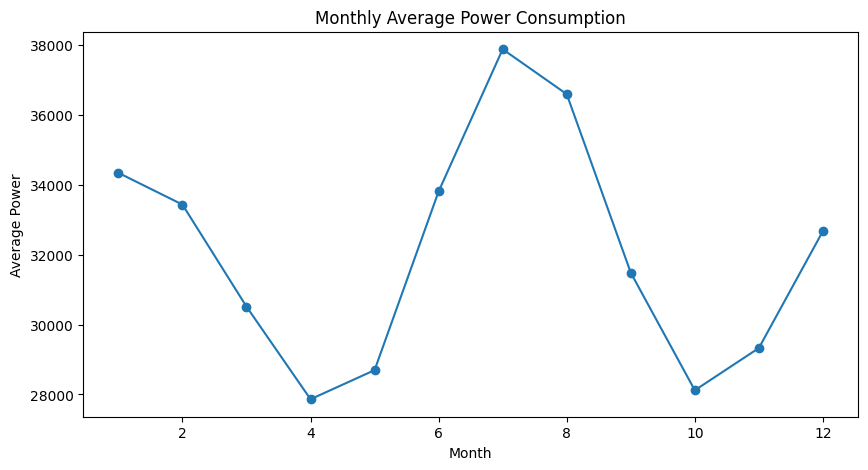

In [17]:
# The 'Month' column already exists in your dataset
monthly = df.groupby("Month")["PJME_MW"].mean()

monthly.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Average Power Consumption")
plt.xlabel("Month")
plt.ylabel("Average Power")
plt.show()

**Weekly Trend**

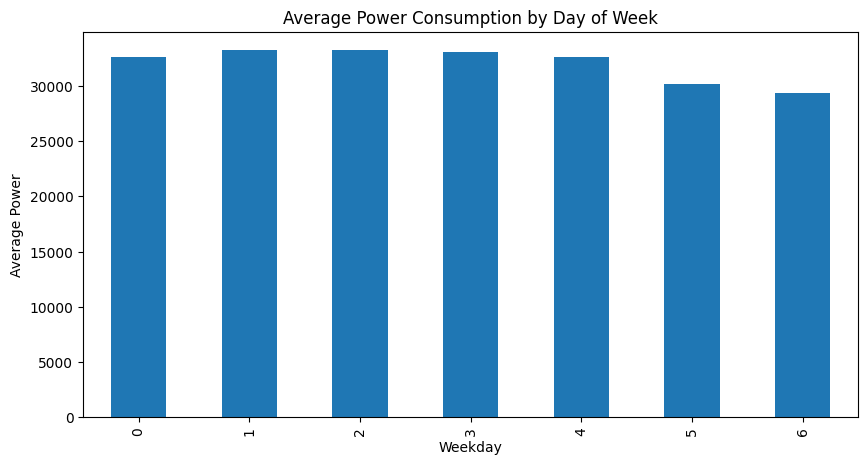

In [18]:
# Since there is no 'Datetime' column, we skip Week for now or base it on available data
# Using DayOfWeek instead
weekly = df.groupby("Weekday")["PJME_MW"].mean()

weekly.plot(kind="bar", figsize=(10,5))
plt.title("Average Power Consumption by Day of Week")
plt.ylabel("Average Power")
plt.show()

**Hour-wise Trend**

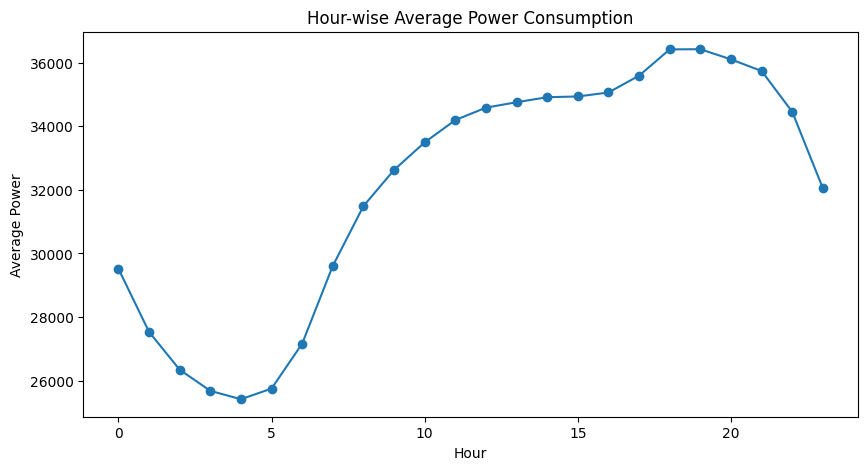

In [19]:
# The 'Hour' column already exists in your dataset
hourly = df.groupby("Hour")["PJME_MW"].mean()

hourly.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Hour-wise Average Power Consumption")
plt.xlabel("Hour")
plt.ylabel("Average Power")
plt.show()